# Análisis de datos: Wine Quality (Red)

Este notebook desarrolla los siguientes pasos solicitados:
1. Importar y cargar los datos del archivo CSV.
2. Realizar una limpieza y preparación básica de los datos.
3. Resumen estadístico de los datos.
4. Matriz de correlación.
5. Al menos 3 gráficos.
6. Conclusiones (mínimo 3 insights relevantes).

## 1. Cargar los datos

In [1]:
import pandas as pd

df = pd.read_csv("winequality-red.csv", sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Limpieza y preparación básica

In [2]:
print("=== Información general del dataset ===")
print(df.info())

print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())


duplicados = df.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {duplicados}")


if duplicados > 0:
    df = df.drop_duplicates()
    print(f"Duplicados eliminados. Nuevo tamaño del dataset: {df.shape}")
else:
    print("No se encontraron duplicados.")


df.head()


=== Información general del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

=== Valores nulos por columna ===
fixed acidity           0
volatile acidity    

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


## 3. Resumen estadístico

In [3]:

resumen = df.describe()
print("=== Resumen estadístico ===")
print(resumen)


resumen


=== Resumen estadístico ===
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1359.000000       1359.000000  1359.000000     1359.000000   
mean        8.310596          0.529478     0.272333        2.523400   
std         1.736990          0.183031     0.195537        1.352314   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.430000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1359.000000          1359.000000           1359.000000  1359.000000   
mean      0.088124            15.893304             46.825975     0.996709   
std       0.049377            10.447270             33.408946     0.001869   
min       0.012000  

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 4. Matriz de correlación

=== Matriz de correlación ===
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.255124     0.667437   
volatile acidity          -0.255124          1.000000    -0.551248   
citric acid                0.667437         -0.551248     1.000000   
residual sugar             0.111025         -0.002449     0.143892   
chlorides                  0.085886          0.055154     0.210195   
free sulfur dioxide       -0.140580         -0.020945    -0.048004   
total sulfur dioxide      -0.103777          0.071701     0.047358   
density                    0.670195          0.023943     0.357962   
pH                        -0.686685          0.247111    -0.550310   
sulphates                  0.190269         -0.256948     0.326062   
alcohol                   -0.061596         -0.197812     0.105108   
quality                    0.119024         -0.395214     0.228057   

                      residual sugar  chlorides  free sulfu

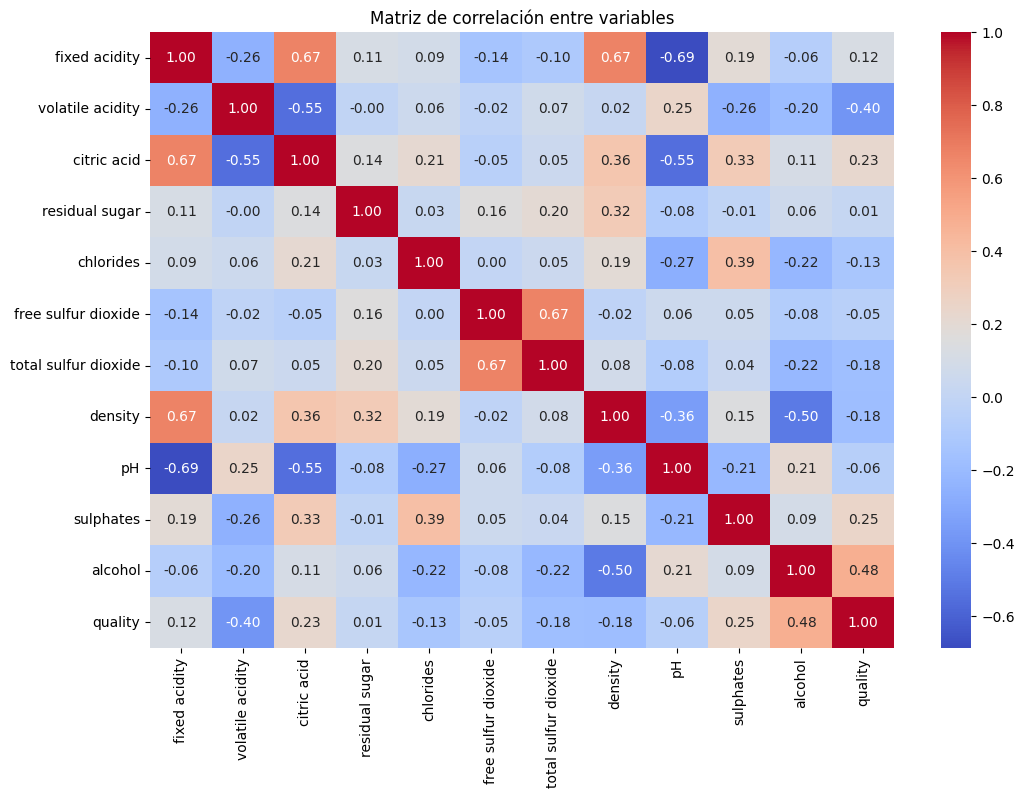

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


corr_matrix = df.corr()

print("=== Matriz de correlación ===")
print(corr_matrix)


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de correlación entre variables")
plt.show()

## 5. Gráficos

C:\Users\Roberto\AppData\Local\Temp\ipykernel_25992\2264340902.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


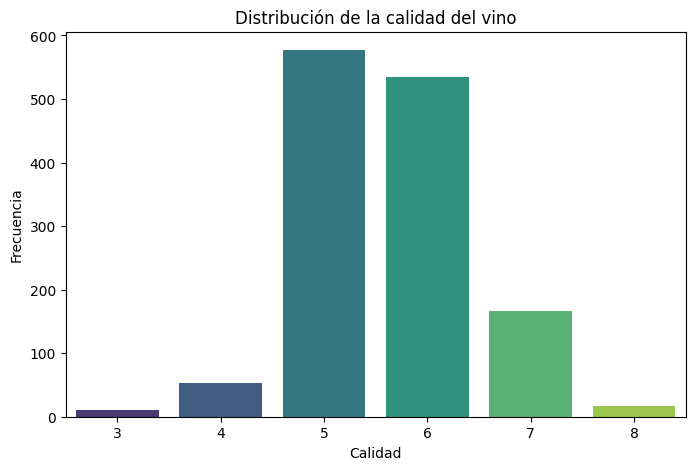

C:\Users\Roberto\AppData\Local\Temp\ipykernel_25992\2264340902.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y="alcohol", data=df, palette="Set2")


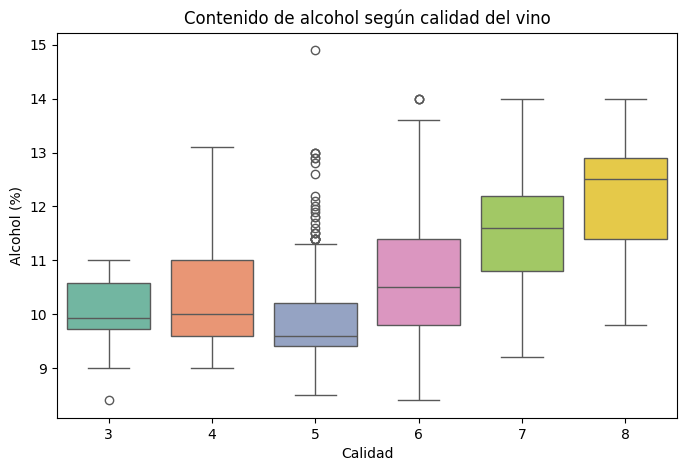

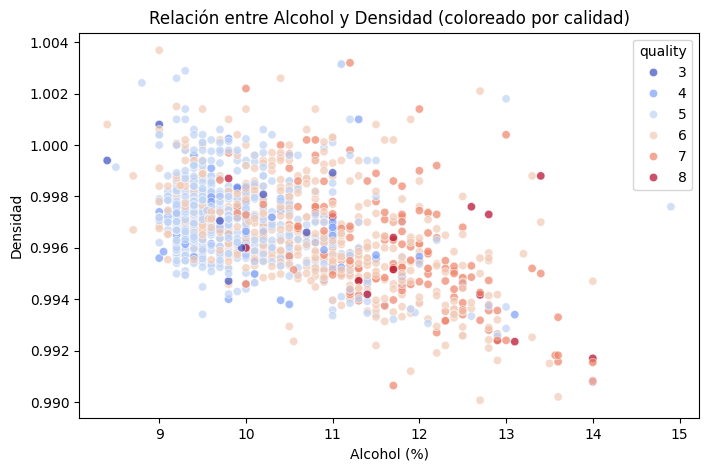

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histograma de la variable 'quality'
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribución de la calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Frecuencia")
plt.show()

# 2. Boxplot: Alcohol vs Calidad
plt.figure(figsize=(8, 5))
sns.boxplot(x="quality", y="alcohol", data=df, palette="Set2")
plt.title("Contenido de alcohol según calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Alcohol (%)")
plt.show()

# 3. Diagrama de dispersión: Alcohol vs Densidad
plt.figure(figsize=(8, 5))
sns.scatterplot(x="alcohol", y="density", hue="quality", data=df, palette="coolwarm", alpha=0.7)
plt.title("Relación entre Alcohol y Densidad (coloreado por calidad)")
plt.xlabel("Alcohol (%)")
plt.ylabel("Densidad")
plt.show()


## 6. Conclusiones


1. **La mayoría de los vinos son de calidad media (5 y 6):**  
   El histograma muestra que la mayor parte de los vinos evaluados se encuentran en una calidad intermedia, lo que indica que el dataset está concentrado en vinos que no son ni de muy baja ni de muy alta calidad. Esto puede sugerir que los productores deben enfocar sus esfuerzos en mejorar ciertos factores para elevar la calidad promedio hacia niveles más altos.

2. **El alcohol influye positivamente en la calidad:**  
   El boxplot evidencia que los vinos con mayor contenido de alcohol tienden a obtener calificaciones de calidad más altas. Esto sugiere que el alcohol es uno de los atributos más influyentes en la percepción de calidad de los catadores.

3. **Relación inversa entre densidad y alcohol:**  
   El gráfico de dispersión muestra que a mayor graduación alcohólica, menor densidad. Además, los vinos de mejor calidad se ubican principalmente en el rango de alta graduación alcohólica y baja densidad, lo que confirma la importancia de estos dos factores combinados en la producción de vinos de calidad superior.